In [1]:
"""
Notebook d'Exploration des Données MNIST
Auteur: Kahina ABBAD - Oussama DEBBOU - Pape Ahmed Fall
Date: Janvier 2026
Objectif: Analyse exploratoire complète du dataset MNIST
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

# Configuration des visualisations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print("=" * 80)
print("\t\t\tEXPLORATION DES DONNÉES")
print("=" * 80)

			EXPLORATION DES DONNÉES


## 1. CHARGEMENT DES DONNÉES

In [2]:
print("\n1. CHARGEMENT DES DONNÉES")
print("-" * 80)

from tensorflow.keras.datasets import mnist

# Charger MNIST
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(f"\n✓ Données chargées avec succès\n")
print(f"  - Training set: {X_train.shape[0]:,} images")
print(f"  - Test set: {X_test.shape[0]:,} images")
print(f"  - Image shape: {X_train.shape[1]}x{X_train.shape[2]} pixels")
print(f"  - Valeurs pixels: [{X_train.min()}, {X_train.max()}]")
print(f"  - Classes: {np.unique(y_train)}")


1. CHARGEMENT DES DONNÉES
--------------------------------------------------------------------------------


2026-01-16 10:14:28.095778: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-16 10:14:29.509799: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-16 10:14:37.302750: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.



✓ Données chargées avec succès

  - Training set: 60,000 images
  - Test set: 10,000 images
  - Image shape: 28x28 pixels
  - Valeurs pixels: [0, 255]
  - Classes: [0 1 2 3 4 5 6 7 8 9]


## 2. STATISTIQUES DESCRIPTIVES

In [3]:
print("\n2. STATISTIQUES DESCRIPTIVES")
print("-" * 80)

# Distribution des classes
class_counts_train = pd.Series(y_train).value_counts().sort_index()
class_counts_test = pd.Series(y_test).value_counts().sort_index()

print("\nDistribution des classes (Training):")
for digit, count in class_counts_train.items():
    percentage = (count / len(y_train)) * 100
    print(f"  Chiffre {digit}: {count:>5} images ({percentage:>5.2f}%)")

print("\nDistribution des classes (Test):")
for digit, count in class_counts_test.items():
    percentage = (count / len(y_test)) * 100
    print(f"  Chiffre {digit}: {count:>5} images ({percentage:>5.2f}%)")


2. STATISTIQUES DESCRIPTIVES
--------------------------------------------------------------------------------

Distribution des classes (Training):
  Chiffre 0:  5923 images ( 9.87%)
  Chiffre 1:  6742 images (11.24%)
  Chiffre 2:  5958 images ( 9.93%)
  Chiffre 3:  6131 images (10.22%)
  Chiffre 4:  5842 images ( 9.74%)
  Chiffre 5:  5421 images ( 9.04%)
  Chiffre 6:  5918 images ( 9.86%)
  Chiffre 7:  6265 images (10.44%)
  Chiffre 8:  5851 images ( 9.75%)
  Chiffre 9:  5949 images ( 9.92%)

Distribution des classes (Test):
  Chiffre 0:   980 images ( 9.80%)
  Chiffre 1:  1135 images (11.35%)
  Chiffre 2:  1032 images (10.32%)
  Chiffre 3:  1010 images (10.10%)
  Chiffre 4:   982 images ( 9.82%)
  Chiffre 5:   892 images ( 8.92%)
  Chiffre 6:   958 images ( 9.58%)
  Chiffre 7:  1028 images (10.28%)
  Chiffre 8:   974 images ( 9.74%)
  Chiffre 9:  1009 images (10.09%)


In [4]:
# Statistiques sur les pixels
print("\nStatistiques sur les intensités de pixels:")
print(f"  - Moyenne: {X_train.mean():.2f}")
print(f"  - Médiane: {np.median(X_train):.2f}")
print(f"  - Écart-type: {X_train.std():.2f}")
print(f"  - Min: {X_train.min()}")
print(f"  - Max: {X_train.max()}")

# Pixels non nuls (indication de la densité d'écriture)
non_zero_pixels = (X_train > 0).sum(axis=(1, 2))
print(f"\nPixels non-nuls par image:")
print(f"  - Moyenne: {non_zero_pixels.mean():.0f} pixels")
print(f"  - Min: {non_zero_pixels.min()} pixels")
print(f"  - Max: {non_zero_pixels.max()} pixels")


Statistiques sur les intensités de pixels:
  - Moyenne: 33.32
  - Médiane: 0.00
  - Écart-type: 78.57
  - Min: 0
  - Max: 255

Pixels non-nuls par image:
  - Moyenne: 150 pixels
  - Min: 34 pixels
  - Max: 351 pixels


## 3. VISUALISATIONS


3. GÉNÉRATION DES VISUALISATIONS
--------------------------------------------------------------------------------


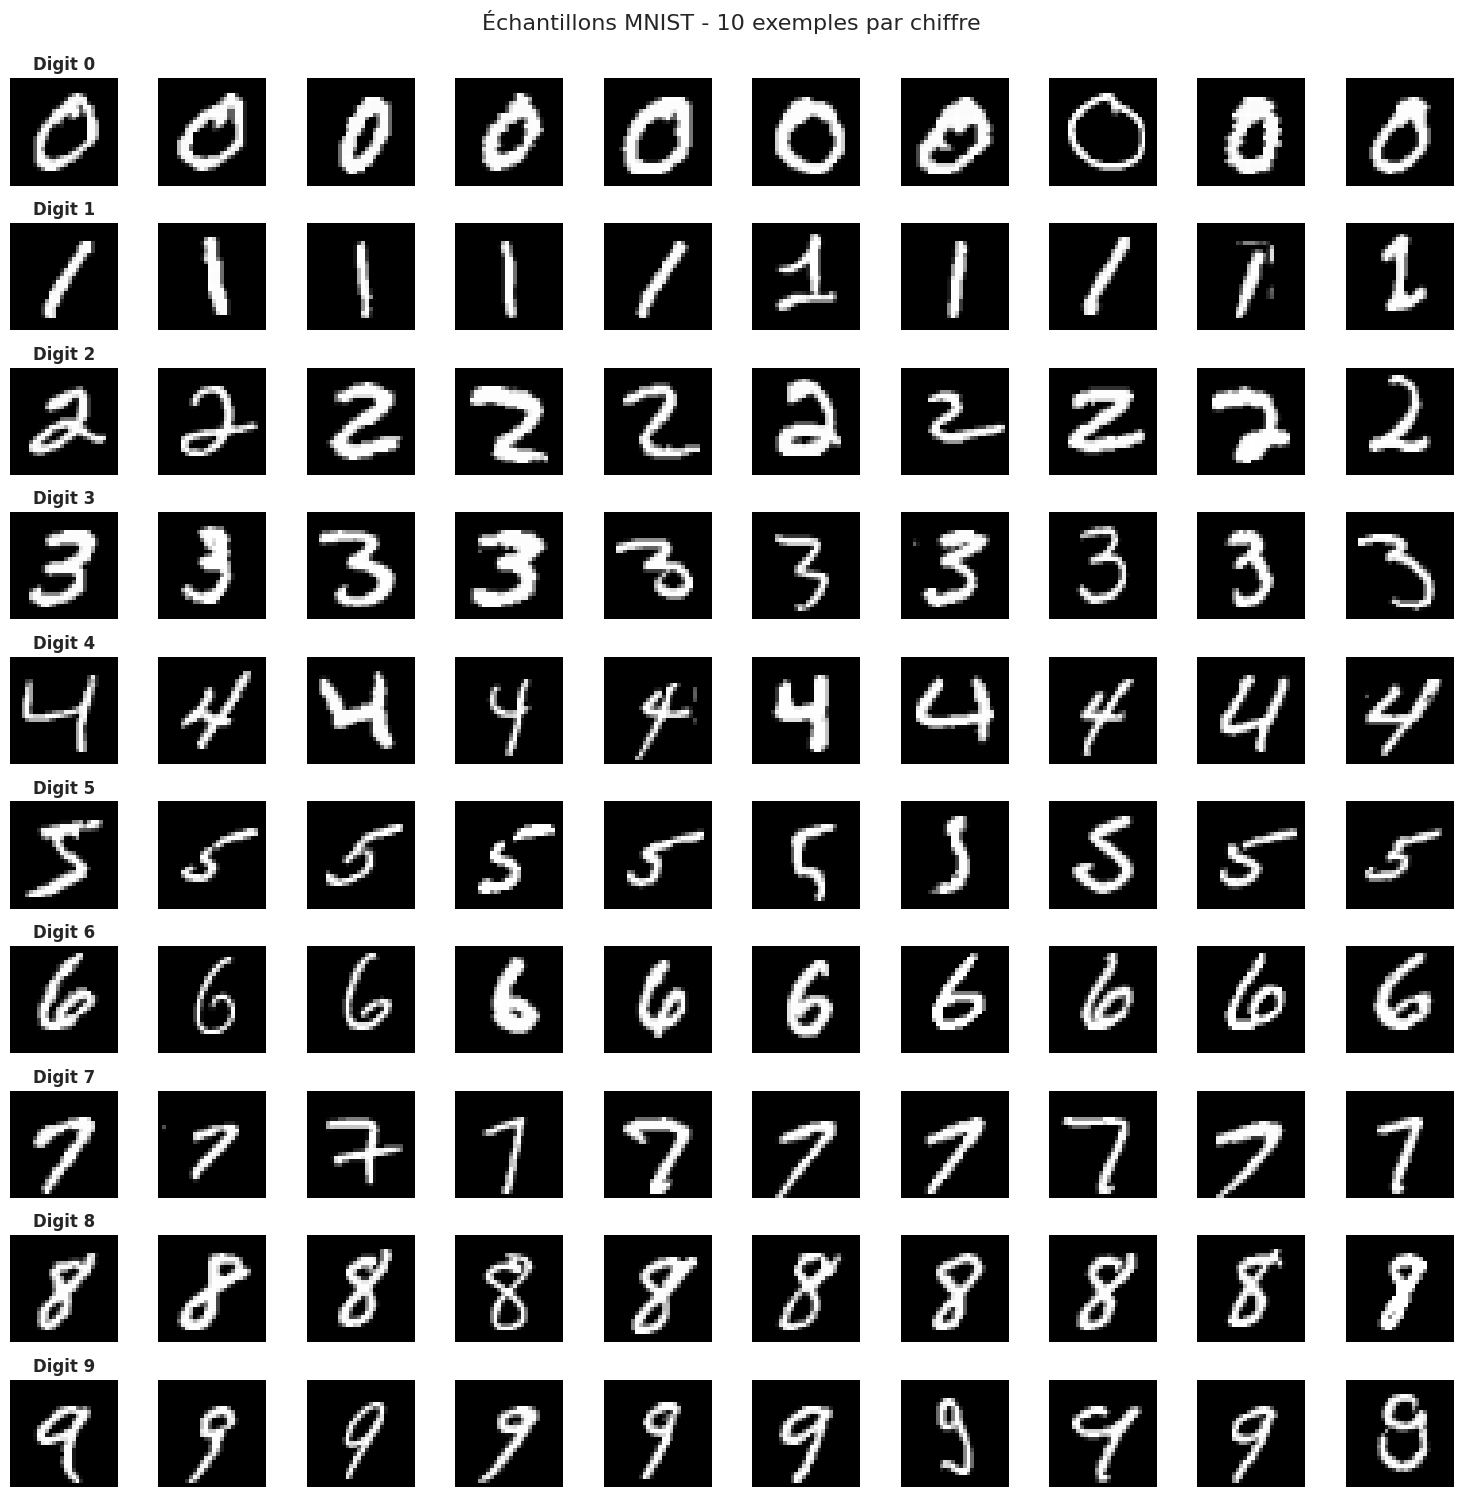

 Figure sauvegardée: mnist_samples.png


In [5]:
print("\n3. GÉNÉRATION DES VISUALISATIONS")
print("-" * 80)

# Figure 1: Exemples d'images par classe
fig, axes = plt.subplots(10, 10, figsize=(15, 15))
fig.suptitle('Échantillons MNIST - 10 exemples par chiffre', fontsize=16, y=0.995)

for digit in range(10):
    # Trouver 10 exemples du chiffre
    digit_indices = np.where(y_train == digit)[0][:10]
    
    for i, idx in enumerate(digit_indices):
        ax = axes[digit, i]
        ax.imshow(X_train[idx], cmap='gray')
        ax.axis('off')
        if i == 0:
            ax.set_title(f'Digit {digit}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()
plt.savefig('visuals/mnist_samples.png', dpi=150, bbox_inches='tight')
print(" Figure sauvegardée: mnist_samples.png")
plt.close()


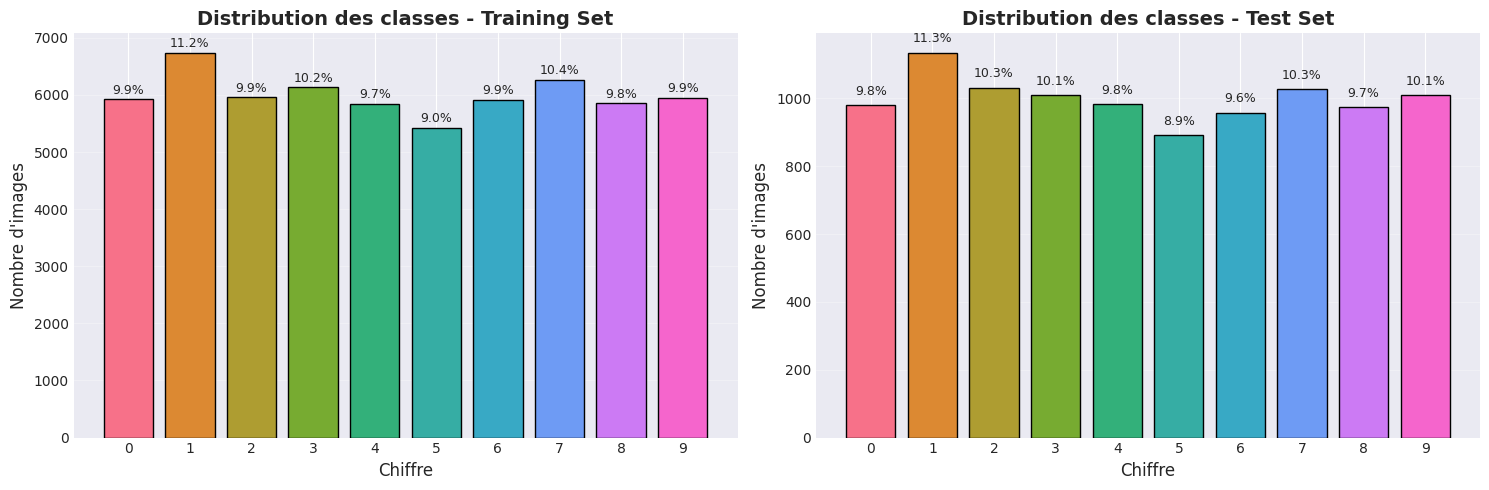

 Figure sauvegardée: class_distribution.png


In [6]:
# Figure 2: Distribution des classes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Training set
ax1.bar(class_counts_train.index, class_counts_train.values, 
        color=sns.color_palette("husl", 10), edgecolor='black')
ax1.set_xlabel('Chiffre', fontsize=12)
ax1.set_ylabel('Nombre d\'images', fontsize=12)
ax1.set_title('Distribution des classes - Training Set', fontsize=14, fontweight='bold')
ax1.set_xticks(range(10))
ax1.grid(axis='y', alpha=0.3)

# Ajouter les pourcentages
for i, (digit, count) in enumerate(class_counts_train.items()):
    percentage = (count / len(y_train)) * 100
    ax1.text(i, count + 100, f'{percentage:.1f}%', ha='center', fontsize=9)

# Test set
ax2.bar(class_counts_test.index, class_counts_test.values,
        color=sns.color_palette("husl", 10), edgecolor='black')
ax2.set_xlabel('Chiffre', fontsize=12)
ax2.set_ylabel('Nombre d\'images', fontsize=12)
ax2.set_title('Distribution des classes - Test Set', fontsize=14, fontweight='bold')
ax2.set_xticks(range(10))
ax2.grid(axis='y', alpha=0.3)

for i, (digit, count) in enumerate(class_counts_test.items()):
    percentage = (count / len(y_test)) * 100
    ax2.text(i, count + 30, f'{percentage:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()
plt.savefig('visuals/class_distribution.png', dpi=150, bbox_inches='tight')
print(" Figure sauvegardée: class_distribution.png")
plt.close()

In [7]:
# Figure 3: Analyse des pixels
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Heatmap moyenne par classe
ax = axes[0, 0]
mean_images = np.array([X_train[y_train == i].mean(axis=0) for i in range(10)])
im = ax.imshow(mean_images.reshape(10, 28*28), cmap='hot', aspect='auto')
ax.set_xlabel('Pixels (28x28 aplati)', fontsize=11)
ax.set_ylabel('Chiffre', fontsize=11)
ax.set_title('Intensité moyenne des pixels par classe', fontsize=13, fontweight='bold')
ax.set_yticks(range(10))
plt.colorbar(im, ax=ax, label='Intensité moyenne')

# Distribution des intensités de pixels
ax = axes[0, 1]
sample_flat = X_train[:5000].flatten()
ax.hist(sample_flat, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax.set_xlabel('Intensité de pixel', fontsize=11)
ax.set_ylabel('Fréquence', fontsize=11)
ax.set_title('Distribution des intensités de pixels (5000 images)', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.axvline(sample_flat.mean(), color='red', linestyle='--', linewidth=2, label=f'Moyenne: {sample_flat.mean():.1f}')
ax.legend()

# Pixels actifs par classe
ax = axes[1, 0]
active_pixels_by_class = [(X_train[y_train == i] > 0).sum(axis=(1,2)).mean() for i in range(10)]
bars = ax.bar(range(10), active_pixels_by_class, color=sns.color_palette("viridis", 10), edgecolor='black')
ax.set_xlabel('Chiffre', fontsize=11)
ax.set_ylabel('Nombre moyen de pixels actifs', fontsize=11)
ax.set_title('Densité d\'écriture par chiffre', fontsize=13, fontweight='bold')
ax.set_xticks(range(10))
ax.grid(axis='y', alpha=0.3)

# Ajouter les valeurs sur les barres
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 5,
            f'{int(height)}', ha='center', va='bottom', fontsize=9)

# Écart-type des pixels
ax = axes[1, 1]
std_by_class = [X_train[y_train == i].std() for i in range(10)]
bars = ax.bar(range(10), std_by_class, color=sns.color_palette("coolwarm", 10), edgecolor='black')
ax.set_xlabel('Chiffre', fontsize=11)
ax.set_ylabel('Écart-type', fontsize=11)
ax.set_title('Variabilité de l\'écriture par chiffre', fontsize=13, fontweight='bold')
ax.set_xticks(range(10))
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('pixel_analysis.png', dpi=150, bbox_inches='tight')
print("✓ Figure sauvegardée: pixel_analysis.png")
plt.close()

✓ Figure sauvegardée: pixel_analysis.png


In [8]:
# Figure 4: Images moyennes par classe
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Image moyenne de chaque chiffre', fontsize=16, fontweight='bold')

for digit in range(10):
    ax = axes[digit // 5, digit % 5]
    mean_img = X_train[y_train == digit].mean(axis=0)
    im = ax.imshow(mean_img, cmap='hot')
    ax.set_title(f'Chiffre {digit}', fontsize=12, fontweight='bold')
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig('mean_digits.png', dpi=150, bbox_inches='tight')
print("✓ Figure sauvegardée: mean_digits.png")
plt.close()

✓ Figure sauvegardée: mean_digits.png


## 4. ANALYSE DE VARIABILITÉ

In [9]:
print("\n4. ANALYSE DE VARIABILITÉ")
print("-" * 80)

# Variance par classe
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Variance des pixels par chiffre (zones de variabilité)', fontsize=16, fontweight='bold')

for digit in range(10):
    ax = axes[digit // 5, digit % 5]
    var_img = X_train[y_train == digit].var(axis=0)
    im = ax.imshow(var_img, cmap='YlOrRd')
    ax.set_title(f'Chiffre {digit}', fontsize=12, fontweight='bold')
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig('variance_digits.png', dpi=150, bbox_inches='tight')
print("✓ Figure sauvegardée: variance_digits.png")
plt.close()



4. ANALYSE DE VARIABILITÉ
--------------------------------------------------------------------------------
✓ Figure sauvegardée: variance_digits.png


## 5. PCA - RÉDUCTION DE DIMENSIONNALITÉ


5. ANALYSE PCA
--------------------------------------------------------------------------------
Calcul de la PCA...
✓ PCA calculée
  - Variance expliquée par 10 composantes: 48.91%
  - Variance expliquée par 50 composantes: 82.88%


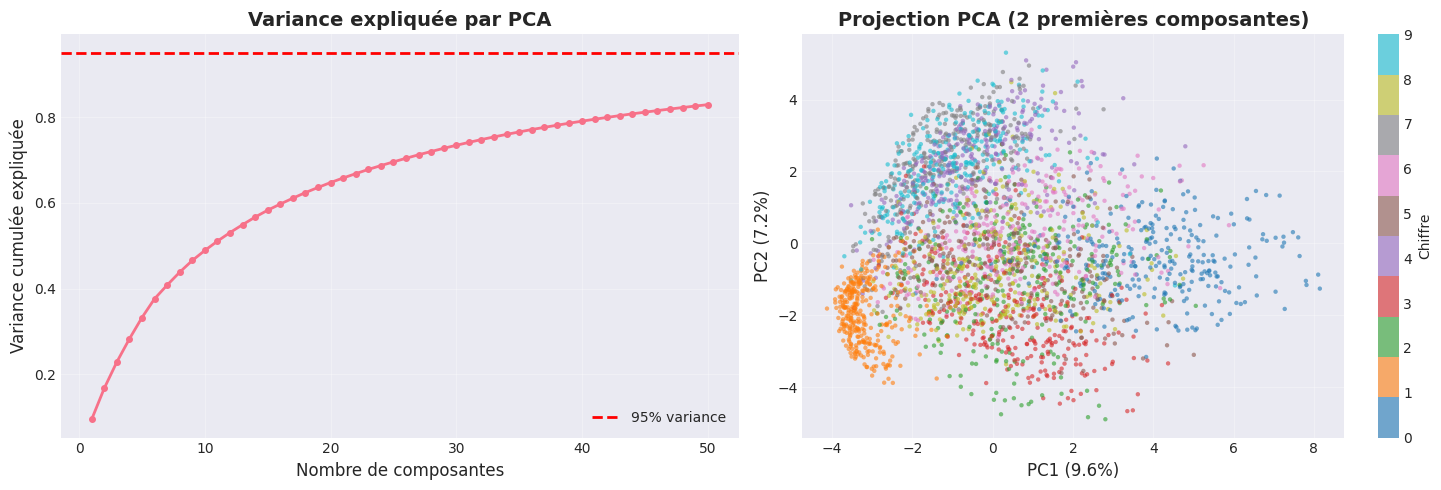

✓ Figure sauvegardée: pca_analysis.png


In [ ]:
print("\n5. ANALYSE PCA")
print("-" * 80)

# Prendre un échantillon pour PCA (plus rapide)
sample_size = 3000
indices = np.random.choice(len(X_train), sample_size, replace=False)
X_sample = X_train[indices].reshape(sample_size, -1)
y_sample = y_train[indices]

# Normaliser
X_sample_norm = X_sample / 255.0

# PCA
print("Calcul de la PCA...")
pca = PCA(n_components=50)
X_pca = pca.fit_transform(X_sample_norm)

X_tsne = TSNE(n_components=2,  random_state=42, learning_rate='auto', perplexity=30).fit_transform(X_pca)

# Variance expliquée
cumsum_variance = np.cumsum(pca.explained_variance_ratio_)
print(f"✓ PCA calculée")
print(f"  - Variance expliquée par 10 composantes: {cumsum_variance[9]*100:.2f}%")
print(f"  - Variance expliquée par 50 composantes: {cumsum_variance[49]*100:.2f}%")

# Visualisation PCA
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Variance expliquée
ax1.plot(range(1, 51), cumsum_variance, marker='o', linestyle='-', linewidth=2, markersize=4)
ax1.axhline(y=0.95, color='r', linestyle='--', linewidth=2, label='95% variance')
ax1.set_xlabel('Nombre de composantes', fontsize=12)
ax1.set_ylabel('Variance cumulée expliquée', fontsize=12)
ax1.set_title('Variance expliquée par PCA', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Projection 2D des 2 premières composantes
scatter = ax2.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_sample, cmap='tab10', 
                      alpha=0.6, s=10, edgecolors='none')
ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
ax2.set_title('Projection PCA (2 premières composantes)', fontsize=14, fontweight='bold')
plt.colorbar(scatter, ax=ax2, label='Chiffre', ticks=range(10))
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.savefig('pca_analysis.png', dpi=150, bbox_inches='tight')
print("✓ Figure sauvegardée: pca_analysis.png")
plt.close()

## 6. DÉTECTION D'ANOMALIES

In [11]:
print("\n6. DÉTECTION D'IMAGES ATYPIQUES")
print("-" * 80)

# Images les plus sombres et les plus claires
brightness = X_train.mean(axis=(1, 2))
darkest_indices = np.argsort(brightness)[:10]
brightest_indices = np.argsort(brightness)[-10:]

fig, axes = plt.subplots(2, 10, figsize=(18, 4))
fig.suptitle('Images atypiques par luminosité', fontsize=16, fontweight='bold')

# Images les plus sombres
for i, idx in enumerate(darkest_indices):
    axes[0, i].imshow(X_train[idx], cmap='gray')
    axes[0, i].set_title(f'{y_train[idx]}\n({brightness[idx]:.1f})', fontsize=9)
    axes[0, i].axis('off')
axes[0, 0].text(-0.5, 0.5, 'Plus sombres', rotation=90, va='center', 
                fontsize=12, fontweight='bold', transform=axes[0, 0].transAxes)

# Images les plus claires
for i, idx in enumerate(brightest_indices):
    axes[1, i].imshow(X_train[idx], cmap='gray')
    axes[1, i].set_title(f'{y_train[idx]}\n({brightness[idx]:.1f})', fontsize=9)
    axes[1, i].axis('off')
axes[1, 0].text(-0.5, 0.5, 'Plus claires', rotation=90, va='center',
                fontsize=12, fontweight='bold', transform=axes[1, 0].transAxes)

plt.tight_layout()
plt.savefig('atypical_images.png', dpi=150, bbox_inches='tight')
print("✓ Figure sauvegardée: atypical_images.png")
plt.close()

print(f"\nImages avec luminosité extrême:")
print(f"  - Plus sombre: {brightness.min():.2f} (label: {y_train[darkest_indices[0]]})")
print(f"  - Plus claire: {brightness.max():.2f} (label: {y_train[brightest_indices[0]]})")


6. DÉTECTION D'IMAGES ATYPIQUES
--------------------------------------------------------------------------------
✓ Figure sauvegardée: atypical_images.png

Images avec luminosité extrême:
  - Plus sombre: 6.49 (label: 1)
  - Plus claire: 101.38 (label: 0)


## 7. MATRICE DE CONFUSION VISUELLE

In [12]:
print("\n7. ANALYSE DE SIMILARITÉ VISUELLE")
print("-" * 80)

# Calculer les images moyennes de chaque classe
mean_images = np.array([X_train[y_train == i].mean(axis=0) for i in range(10)])

# Calculer la similarité (corrélation) entre les chiffres
from scipy.spatial.distance import pdist, squareform
similarity_matrix = 1 - squareform(pdist(mean_images.reshape(10, -1), metric='correlation'))

# Visualisation
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(similarity_matrix, cmap='RdYlGn', vmin=0, vmax=1)
ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xlabel('Chiffre', fontsize=12)
ax.set_ylabel('Chiffre', fontsize=12)
ax.set_title('Matrice de similarité visuelle entre chiffres', fontsize=14, fontweight='bold')

# Ajouter les valeurs
for i in range(10):
    for j in range(10):
        text = ax.text(j, i, f'{similarity_matrix[i, j]:.2f}',
                      ha="center", va="center", color="black", fontsize=9)

plt.colorbar(im, ax=ax, label='Similarité')
plt.tight_layout()
plt.savefig('similarity_matrix.png', dpi=150, bbox_inches='tight')
print("✓ Figure sauvegardée: similarity_matrix.png")
plt.close()

# Trouver les paires les plus similaires
similar_pairs = []
for i in range(10):
    for j in range(i+1, 10):
        similar_pairs.append((i, j, similarity_matrix[i, j]))
similar_pairs.sort(key=lambda x: x[2], reverse=True)

print("\nPaires de chiffres les plus similaires visuellement:")
for i, (digit1, digit2, sim) in enumerate(similar_pairs[:5], 1):
    print(f"  {i}. Chiffres {digit1} et {digit2}: {sim:.3f}")


7. ANALYSE DE SIMILARITÉ VISUELLE
--------------------------------------------------------------------------------
✓ Figure sauvegardée: similarity_matrix.png

Paires de chiffres les plus similaires visuellement:
  1. Chiffres 4 et 9: 0.898
  2. Chiffres 5 et 8: 0.869
  3. Chiffres 7 et 9: 0.854
  4. Chiffres 3 et 5: 0.849
  5. Chiffres 3 et 8: 0.818


## 8. RECOMMANDATIONS PREPROCESSING

In [13]:
print("\n" + "=" * 80)
print("RECOMMANDATIONS POUR LE PREPROCESSING")
print("=" * 80)

recommendations = """
1. NORMALISATION
   ✓ Normaliser les pixels [0, 255] → [0, 1] : X / 255.0
   ✓ Ou standardisation (mean=0, std=1) si meilleure performance

2. RESHAPE POUR CNN
   ✓ Shape actuelle: (n_samples, 28, 28)
   ✓ Shape pour CNN: (n_samples, 28, 28, 1)
   ✓ Commande: X.reshape(-1, 28, 28, 1)

3. ONE-HOT ENCODING DES LABELS
   ✓ Utiliser keras.utils.to_categorical(y, 10)
   ✓ Transformation: [3] → [0,0,0,1,0,0,0,0,0,0]

4. DATA AUGMENTATION (pour améliorer performance)
   ✓ Rotation: ±15 degrés
   ✓ Translation: ±10% hauteur/largeur
   ✓ Zoom: ±10% 
   ✓ PAS de flip horizontal (changerait le sens des chiffres)

5. VALIDATION SPLIT
   ✓ Train/Val split: 80/20 ou 90/10
   ✓ Ou utiliser validation_split=0.2 dans model.fit()

6. BATCH NORMALIZATION
   ✓ Ajouter après chaque couche Dense/Conv2D
   ✓ Stabilise l'apprentissage

7. ATTENTION AUX CHIFFRES SIMILAIRES
   ✓ Paires difficiles: 4/9, 3/8, 5/6, 1/7
   ✓ Monitoring spécifique de ces confusions
"""

print(recommendations)


RECOMMANDATIONS POUR LE PREPROCESSING

1. NORMALISATION
   ✓ Normaliser les pixels [0, 255] → [0, 1] : X / 255.0
   ✓ Ou standardisation (mean=0, std=1) si meilleure performance

2. RESHAPE POUR CNN
   ✓ Shape actuelle: (n_samples, 28, 28)
   ✓ Shape pour CNN: (n_samples, 28, 28, 1)
   ✓ Commande: X.reshape(-1, 28, 28, 1)

3. ONE-HOT ENCODING DES LABELS
   ✓ Utiliser keras.utils.to_categorical(y, 10)
   ✓ Transformation: [3] → [0,0,0,1,0,0,0,0,0,0]

4. DATA AUGMENTATION (pour améliorer performance)
   ✓ Rotation: ±15 degrés
   ✓ Translation: ±10% hauteur/largeur
   ✓ Zoom: ±10% 
   ✓ PAS de flip horizontal (changerait le sens des chiffres)

5. VALIDATION SPLIT
   ✓ Train/Val split: 80/20 ou 90/10
   ✓ Ou utiliser validation_split=0.2 dans model.fit()

6. BATCH NORMALIZATION
   ✓ Ajouter après chaque couche Dense/Conv2D
   ✓ Stabilise l'apprentissage

7. ATTENTION AUX CHIFFRES SIMILAIRES
   ✓ Paires difficiles: 4/9, 3/8, 5/6, 1/7
   ✓ Monitoring spécifique de ces confusions



## 9. RÉSUMÉ STATISTIQUE

In [14]:
print("\n" + "=" * 80)
print("RÉSUMÉ DE L'ANALYSE EXPLORATOIRE")
print("=" * 80)

summary = f"""
DATASET
  • Training: {len(X_train):,} images
  • Test: {len(X_test):,} images
  • Shape: 28x28 pixels (784 features)
  • Classes: 10 chiffres (0-9)

DISTRIBUTION
  • Classes équilibrées: ~10% par chiffre
  • Légère variation: {class_counts_train.min()} - {class_counts_train.max()} images par classe

CARACTÉRISTIQUES PIXELS
  • Range: [0, 255] (niveaux de gris)
  • Moyenne globale: {X_train.mean():.2f}
  • Pixels actifs moyens: {non_zero_pixels.mean():.0f}/{28*28} ({non_zero_pixels.mean()/(28*28)*100:.1f}%)
  • Forte concentration au centre (écriture centrée)

VARIABILITÉ
  • Chiffres avec plus de variabilité: {', '.join([str(i) for i in np.argsort(std_by_class)[-3:][::-1]])}
  • Chiffres les plus stables: {', '.join([str(i) for i in np.argsort(std_by_class)[:3]])}

PCA
  • 50 composantes expliquent {cumsum_variance[49]*100:.1f}% de la variance
  • Forte réduction dimensionnelle possible

SIMILARITÉ VISUELLE
  • Paires similaires: {similar_pairs[0][0]}-{similar_pairs[0][1]} ({similar_pairs[0][2]:.3f}), {similar_pairs[1][0]}-{similar_pairs[1][1]} ({similar_pairs[1][2]:.3f})
  • Risque de confusion sur ces paires

QUALITÉ DES DONNÉES
  ✓ Données propres et bien formatées
  ✓ Pas de valeurs manquantes
  ✓ Centrage et normalisation cohérents
  ✓ Prêt pour la modélisation
"""

print(summary)



RÉSUMÉ DE L'ANALYSE EXPLORATOIRE

DATASET
  • Training: 60,000 images
  • Test: 10,000 images
  • Shape: 28x28 pixels (784 features)
  • Classes: 10 chiffres (0-9)

DISTRIBUTION
  • Classes équilibrées: ~10% par chiffre
  • Légère variation: 5421 - 6742 images par classe

CARACTÉRISTIQUES PIXELS
  • Range: [0, 255] (niveaux de gris)
  • Moyenne globale: 33.32
  • Pixels actifs moyens: 150/784 (19.1%)
  • Forte concentration au centre (écriture centrée)

VARIABILITÉ
  • Chiffres avec plus de variabilité: 0, 2, 8
  • Chiffres les plus stables: 1, 7, 4

PCA
  • 50 composantes expliquent 82.5% de la variance
  • Forte réduction dimensionnelle possible

SIMILARITÉ VISUELLE
  • Paires similaires: 4-9 (0.898), 5-8 (0.869)
  • Risque de confusion sur ces paires

QUALITÉ DES DONNÉES
  ✓ Données propres et bien formatées
  ✓ Pas de valeurs manquantes
  ✓ Centrage et normalisation cohérents
  ✓ Prêt pour la modélisation

